# 06 · Evaluación — Diagnóstico de utilidad (comparación de los 3 modelos)

Un AUC de 0.76 no le dice nada al equipo de retención. Esta evaluación traduce los
modelos a **decisiones**: ¿son confiables las probabilidades?, ¿a cuántas vendedoras
conviene contactar?, ¿cuánto valor incremental genera frente a no tener modelo?

Comparamos **lado a lado los tres candidatos tuneados** — XGBoost, Random Forest y
Regresión Logística (elasticnet). La **tabla de métricas reproduce la Tabla 2** del
capítulo de modelado (mismas definiciones: AUC GroupKFold de la nested-CV, AUC OOT,
Recall OOT a t=0.5 y **Top Decil Lift** con decil `= n//10`). El **criterio rector
para el modelo final es el Top Decil Lift**, donde gana XGBoost.

Todo se mide sobre el **test OOT** — el escenario real: entrenar con el pasado,
priorizar el próximo período.

## Qué incluye

1. **Métricas globales (Tabla 2)** — AUC GroupKFold, AUC OOT, Recall OOT y Top Decil
   Lift de los tres modelos.
2. **Calibración** *(diagnóstico complementario)* — ¿una `p(churn)=0.7` corresponde
   a ~70% de churn? El Brier es solo de apoyo, no entra en la selección.
3. **Discriminación** — curvas ROC y Precision-Recall superpuestas.
4. **Ganancias y lift acumulados** — el corazón del *targeting*: si contacto al
   top X% por score, ¿qué fracción de los churners capturo?
5. **Puntos de operación** — lift y recall por % contactado, comparados.
6. **Matriz de confusión** de cada modelo en el umbral recomendado.
7. **Costo-beneficio** — valor neto esperado según supuestos del negocio (editables).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent

df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
prev = y_test.mean()


def _reconstruir(key):
    """Reentrena un modelo desde sus hiperparámetros (fallback si falta el .joblib)."""
    best = json.load(open(base / "05_modelling" / f"{key}_best_params.json"))["best_params"]
    if key == "xgboost":
        from xgboost import XGBClassifier
        spw = (y_train == 0).sum() / (y_train == 1).sum()
        m = XGBClassifier(**best, scale_pos_weight=spw, eval_metric="logloss",
                          tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
    elif key == "rf":
        from sklearn.ensemble import RandomForestClassifier
        m = RandomForestClassifier(**best, class_weight="balanced", n_jobs=-1,
                                   random_state=RANDOM_STATE)
    else:  # logreg: StandardScaler + LogisticRegression elasticnet (saga)
        from sklearn.pipeline import make_pipeline
        from sklearn.preprocessing import StandardScaler
        from sklearn.linear_model import LogisticRegression
        m = make_pipeline(
            StandardScaler(),
            LogisticRegression(**best, penalty="elasticnet", solver="saga",
                               class_weight="balanced", max_iter=1000,
                               random_state=RANDOM_STATE))
    m.fit(X_train, y_train)
    return m


# (etiqueta, archivo .joblib, key de params, color) — orden de presentación
SPECS = [("XGBoost",       "xgboost_tuned", "xgboost", "#4c72b0"),
         ("Random Forest", "rf_tuned",      "rf",      "#55a868"),
         ("LogReg",        "logreg_tuned",  "logreg",  "#c44e52")]
COLOR = {label: c for label, _, _, c in SPECS}
LABELS = [s[0] for s in SPECS]

# Cada modelo se entrenó sobre el train OOT → lo evaluamos sobre el test OOT (fuera de
# muestra). El LogReg es un Pipeline (StandardScaler interno), así que predict_proba
# opera sobre X sin escalado manual, igual que los modelos de árbol.
models, P = {}, {}      # P[label] = p(churn) sobre el test OOT
for label, fname, key, _ in SPECS:
    fp = base / "models" / f"{fname}.joblib"
    models[label] = joblib.load(fp) if fp.exists() else _reconstruir(key)
    P[label] = models[label].predict_proba(X_test)[:, 1]
    estado = "cargado" if fp.exists() else "reconstruido"
    print(f"{label:14s} {estado:12s} · p(churn) listo")

print(f"\ntest OOT: {test_mask.sum():,} filas | prevalencia churn {prev:.3f}")

XGBoost        cargado      · p(churn) listo
Random Forest  cargado      · p(churn) listo
LogReg         cargado      · p(churn) listo

test OOT: 803 filas | prevalencia churn 0.262


In [2]:
from sklearn.metrics import roc_auc_score, recall_score


def top_decile_lift(yt, p):
    """Lift del decil top, MISMA definición que la etapa 05 (decil = len(yt)//10)."""
    k = max(len(yt) // 10, 1)
    return yt[np.argsort(-p)[:k]].mean() / yt.mean()


# AUC GroupKFold: validación interna del tuning (nested-CV), leída de los
# *_best_params.json. Es la misma columna de la Tabla 2 → no se recomputa aquí.
gkf_auc = {l: json.load(open(base / "05_modelling" / f"{key}_best_params.json"))
                      ["best_value_cv_auc_trainpool"]
           for l, _, key, _ in SPECS}

tabla2 = pd.DataFrame({
    "AUC_GroupKFold": gkf_auc,
    "AUC_OOT":        {l: roc_auc_score(y_test, P[l]) for l in LABELS},
    "Recall_OOT":     {l: recall_score(y_test, (P[l] >= 0.5).astype(int)) for l in LABELS},
    "Top_Decil_Lift": {l: top_decile_lift(y_test, P[l]) for l in LABELS},
}).loc[LABELS]

print("Tabla 2 — modelos tuneados (Recall y TDL OOT a t=0.5 / decil //10):\n")
print(tabla2.round(4).to_string())

mejor_tdl = tabla2["Top_Decil_Lift"].idxmax()
print(f"\nMejor Top Decil Lift: {mejor_tdl} ({tabla2.loc[mejor_tdl, 'Top_Decil_Lift']:.2f})"
      "  → criterio rector para el modelo final")

Tabla 2 — modelos tuneados (Recall y TDL OOT a t=0.5 / decil //10):

               AUC_GroupKFold  AUC_OOT  Recall_OOT  Top_Decil_Lift
XGBoost                0.7422   0.7648      0.7762          2.4377
Random Forest          0.7399   0.7590      0.7286          2.3421
LogReg                 0.7394   0.7693      0.7333          2.2465

Mejor Top Decil Lift: XGBoost (2.44)  → criterio rector para el modelo final


## 1 · Calibración  *(diagnóstico complementario)*

> No entra en la selección del modelo (esa se decide con la Tabla 2 / Top Decil
> Lift). Se incluye solo para saber si las probabilidades son usables tal cual.

El *reliability diagram* agrupa las predicciones en bins y compara la probabilidad
predicha promedio contra la frecuencia real de churn. Sobre la diagonal = calibrado.
Los tres modelos usan **reponderación de clases** (`scale_pos_weight` en XGBoost,
`class_weight="balanced"` en RF y LogReg), lo que **infla las probabilidades** hacia
la clase positiva → es esperable que las curvas queden por debajo de la diagonal. El
`Brier` que se muestra es solo de apoyo; si el modelo elegido (XGBoost) quedara
descalibrado, se recalibra con `CalibratedClassifierCV` sin reentrenar — el ranking
para priorizar (que es lo que usa el targeting) no se ve afectado.

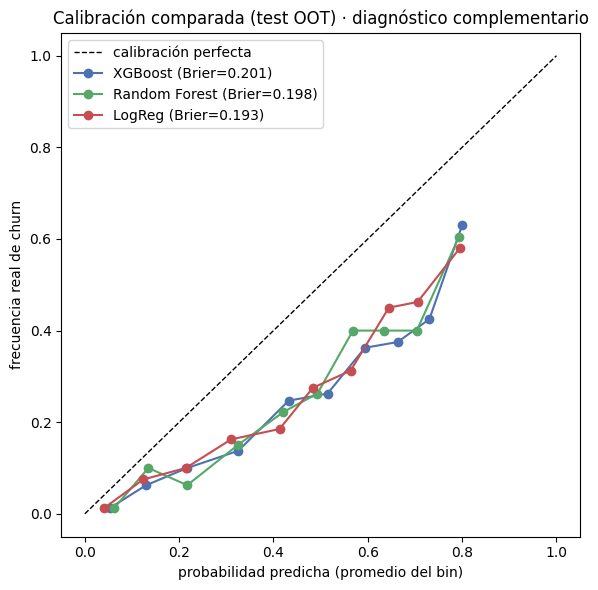

In [3]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="calibración perfecta")
for l in LABELS:
    frac_pos, mean_pred = calibration_curve(y_test, P[l], n_bins=10, strategy="quantile")
    b = brier_score_loss(y_test, P[l])
    ax.plot(mean_pred, frac_pos, "o-", color=COLOR[l], label=f"{l} (Brier={b:.3f})")
ax.set_xlabel("probabilidad predicha (promedio del bin)")
ax.set_ylabel("frecuencia real de churn")
ax.set_title("Calibración comparada (test OOT) · diagnóstico complementario")
ax.legend(); plt.tight_layout(); plt.show()

## 2 · Discriminación: ROC y Precision-Recall

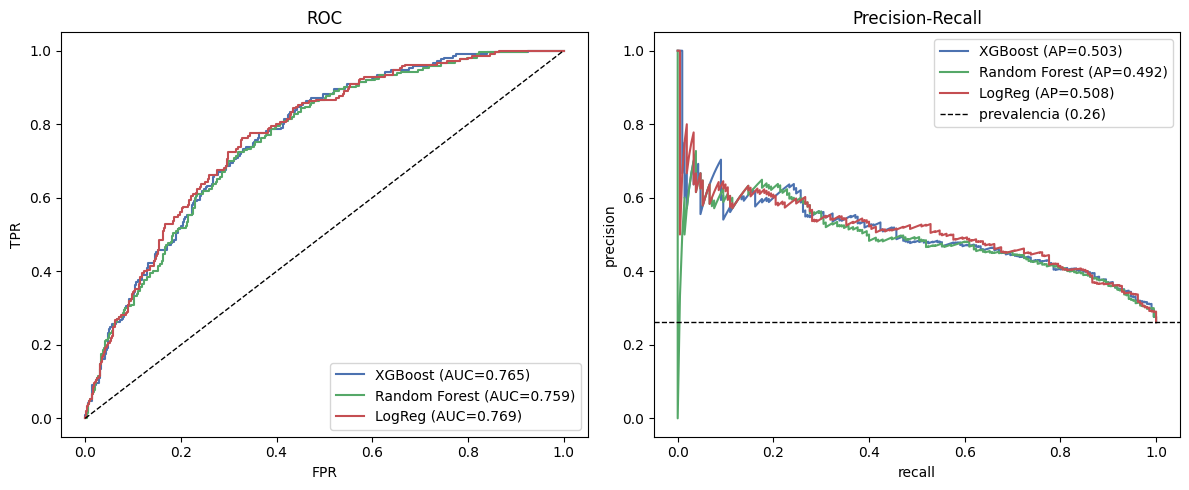

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for l in LABELS:
    fpr, tpr, _ = roc_curve(y_test, P[l])
    prec, rec, _ = precision_recall_curve(y_test, P[l])
    auc = roc_auc_score(y_test, P[l]); apv = average_precision_score(y_test, P[l])
    ax[0].plot(fpr, tpr, color=COLOR[l], label=f"{l} (AUC={auc:.3f})")
    ax[1].plot(rec, prec, color=COLOR[l], label=f"{l} (AP={apv:.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=1)
ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].axhline(prev, color="k", ls="--", lw=1, label=f"prevalencia ({prev:.2f})")
ax[1].set_title("Precision-Recall"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
ax[1].legend()
plt.tight_layout(); plt.show()

## 3 · Ganancias y lift acumulados

Ordenamos a las vendedoras por score descendente (las que el modelo cree más en
riesgo primero) y acumulamos:

- **Curva de ganancias**: % de churners capturados vs % de la base contactada. La
  diagonal es el azar; cuanto más arriba la curva, mejor el *targeting*.
- **Curva de lift**: cuántas veces más churners encuentro en el top X% frente a
  elegir al azar.

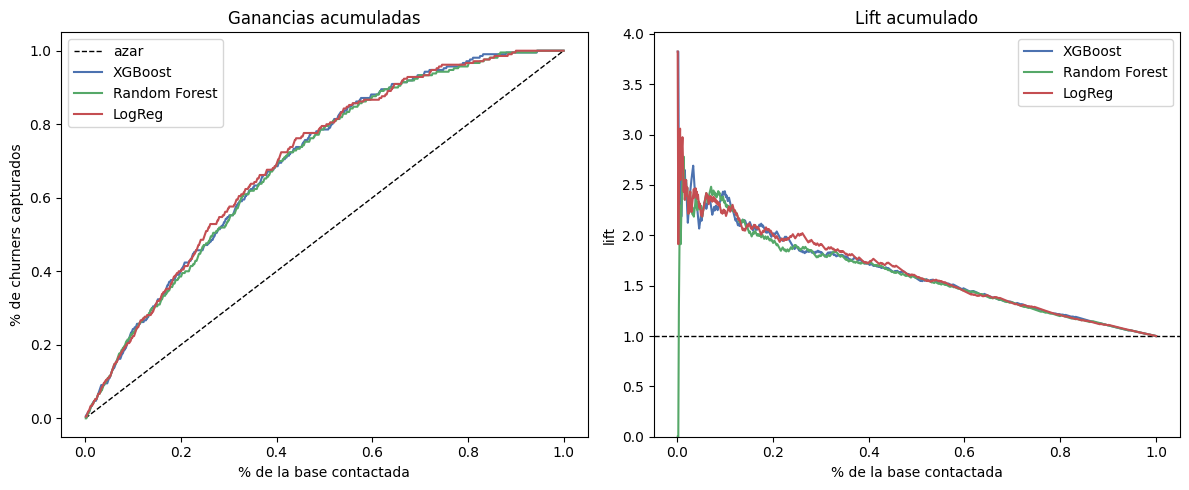

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="azar")
ax[1].axhline(1, color="k", ls="--", lw=1)
for l in LABELS:
    order = np.argsort(-P[l])
    y_sorted = y_test[order]
    frac_contacted = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    frac_captured = np.cumsum(y_sorted) / y_sorted.sum()
    ax[0].plot(frac_contacted, frac_captured, color=COLOR[l], label=l)
    ax[1].plot(frac_contacted, frac_captured / frac_contacted, color=COLOR[l], label=l)
ax[0].set_title("Ganancias acumuladas")
ax[0].set_xlabel("% de la base contactada"); ax[0].set_ylabel("% de churners capturados")
ax[0].legend()
ax[1].set_title("Lift acumulado")
ax[1].set_xlabel("% de la base contactada"); ax[1].set_ylabel("lift"); ax[1].set_ylim(bottom=0)
ax[1].legend()
plt.tight_layout(); plt.show()

## 4 · Puntos de operación (comparados)

Si el equipo de retención contacta al **top X% por score**, ¿cuántos churners
captura cada modelo? Mostramos dos pivotes lado a lado:

- **LIFT vs prevalencia** — cuántas veces más churners hay en el top X% del modelo
  que contactando al mismo X% al azar (1.0 = sin valor; más alto = mejor *targeting*).
- **RECALL** — qué fracción del total de churners se captura en ese top X%.

A `% bajos` (top 5–10%) manda la precision/lift (poca capacidad, máxima
concentración); a `% altos` manda el recall (cobertura). El mejor modelo es el que
domina en la franja donde el equipo realmente va a operar.

In [6]:
n = len(y_test); total_pos = int(y_test.sum())
ks = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
rows = []
for l in LABELS:
    order = np.argsort(-P[l])
    for k in ks:
        m = int(k * n)                    # floor, igual que el decil //10 de la Tabla 2
        tp = int(y_test[order[:m]].sum())
        rows.append({"modelo": l, "regla": f"top {int(k*100)}%",
                     "precision": tp / m, "recall": tp / total_pos,
                     "lift": (tp / m) / prev})
ops = pd.DataFrame(rows)
idx = [f"top {int(k*100)}%" for k in ks]

print("LIFT vs prevalencia (top X% por score · top 10% = Top Decil Lift de la Tabla 2):")
print(ops.pivot(index="regla", columns="modelo", values="lift").loc[idx, LABELS].round(3).to_string())
print("\nRECALL (fracción de churners capturados):")
print(ops.pivot(index="regla", columns="modelo", values="recall").loc[idx, LABELS].round(3).to_string())

LIFT vs prevalencia (top X% por score · top 10% = Top Decil Lift de la Tabla 2):
modelo   XGBoost  Random Forest  LogReg
regla                                  
top 5%     2.199          2.294   2.199
top 10%    2.438          2.342   2.246
top 15%    2.103          2.039   2.103
top 20%    2.008          1.936   2.008
top 30%    1.832          1.800   1.912
top 50%    1.573          1.583   1.592

RECALL (fracción de churners capturados):
modelo   XGBoost  Random Forest  LogReg
regla                                  
top 5%     0.110          0.114   0.110
top 10%    0.243          0.233   0.224
top 15%    0.314          0.305   0.314
top 20%    0.400          0.386   0.400
top 30%    0.548          0.538   0.571
top 50%    0.786          0.790   0.795


## 5 · Matriz de confusión (umbral t = 0.5)

Una por modelo, en el mismo umbral. Lectura para retención: **falsos negativos** =
churners que no contactamos (la pérdida que queremos evitar); **falsos positivos** =
vendedoras sanas contactadas (costo del contacto, usualmente bajo).

Ojo al comparar a t=0.5 fijo: como los tres modelos reponderan clases, el 0.5 **no
es el mismo punto operativo** en cada uno (mueve cuántas marca como churn). Para
decidir capacidad, la sección 4 (top X%) es más justa; esto es solo una foto del
trade-off de cada modelo en un umbral común.

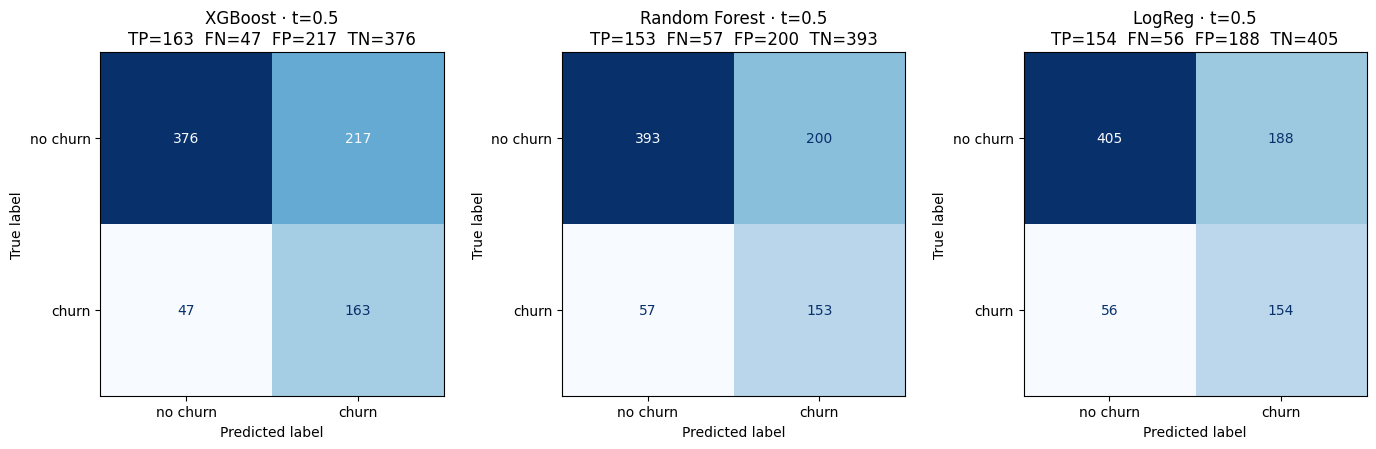

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

t = 0.5
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, l in zip(axes, LABELS):
    pred = (P[l] >= t).astype(int)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["no churn", "churn"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{l} · t={t}\nTP={tp}  FN={fn}  FP={fp}  TN={tn}")
plt.tight_layout(); plt.show()

## 6 · Costo-beneficio (supuestos editables)

Traduce cada punto de operación a **valor neto esperado**. Los tres parámetros de
abajo son **supuestos** — reemplázalos con números reales del negocio:

- `COSTO_CONTACTO`: costo de contactar a una vendedora (llamada, incentivo).
- `VALOR_RETENCION`: margen futuro de retener a una churner real.
- `TASA_EXITO`: probabilidad de que el contacto efectivamente la retenga.

Valor neto = (churners capturados × `TASA_EXITO` × `VALOR_RETENCION`)
− (contactadas × `COSTO_CONTACTO`). El óptimo indica **hasta qué % conviene contactar**.

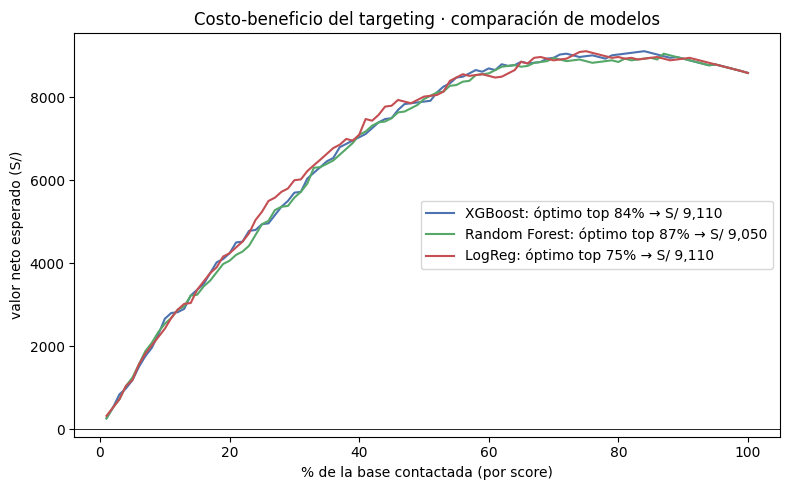

       modelo  top_opt_%  valor_neto
      XGBoost         84      9110.0
       LogReg         75      9110.0
Random Forest         87      9050.0

NOTA: el ganador en valor neto depende de los supuestos (COSTO/VALOR/TASA).
Ajustar con cifras reales del negocio antes de decidir.


In [8]:
# --- SUPUESTOS: reemplazar con cifras reales del negocio ---
COSTO_CONTACTO = 5.0       # S/ por vendedora contactada
VALOR_RETENCION = 200.0    # S/ de margen por churner retenida
TASA_EXITO = 0.30          # prob. de retención efectiva al contactar a una churner real

fracs = np.linspace(0.01, 1.0, 100)
fig, ax = plt.subplots(figsize=(8, 5))
cb = []
for l in LABELS:
    order = np.argsort(-P[l])
    neto = np.array([
        int(y_test[order[:int(k * n)]].sum()) * TASA_EXITO * VALOR_RETENCION
        - int(k * n) * COSTO_CONTACTO
        for k in fracs])
    k_opt = fracs[neto.argmax()]
    ax.plot(fracs * 100, neto, color=COLOR[l],
            label=f"{l}: óptimo top {k_opt*100:.0f}% → S/ {neto.max():,.0f}")
    cb.append({"modelo": l, "top_opt_%": round(k_opt * 100), "valor_neto": neto.max()})
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("% de la base contactada (por score)")
ax.set_ylabel("valor neto esperado (S/)")
ax.set_title("Costo-beneficio del targeting · comparación de modelos")
ax.legend(); plt.tight_layout(); plt.show()

cb = pd.DataFrame(cb).sort_values("valor_neto", ascending=False)
print(cb.to_string(index=False))
print("\nNOTA: el ganador en valor neto depende de los supuestos (COSTO/VALOR/TASA).")
print("Ajustar con cifras reales del negocio antes de decidir.")

## 7 · Síntesis y elección del modelo

**Modelo final: XGBoost**, por **Top Decil Lift** (criterio rector del negocio).

- **Top Decil Lift (decisivo)**: en la franja de capacidad real del equipo de
  retención (top 10%), XGBoost captura más churners por contacto que RF y LogReg:
  **2.44 vs 2.34 vs 2.25**. Para una campaña con presupuesto acotado de contactos,
  este es el criterio que más valor aporta → define la elección.
- **Discriminación (AUC)**: empate dentro del ruido — AUC OOT 0.765 (XGBoost), 0.769
  (LogReg), 0.759 (RF), con ±0.03 de variabilidad mensual. LogReg lidera por un pelo
  pero **no de forma significativa**, así que elegir XGBoost no cuesta AUC relevante.
- **Recall OOT a t=0.5**: XGBoost es el más alto (**0.776** vs 0.733 LogReg, 0.729
  RF) → en el umbral por defecto deja menos churners sin contactar (menos falsos
  negativos, la pérdida a evitar).
- **Calibración (complementaria)**: las tres curvas quedan por debajo de la diagonal
  (probabilidades infladas por la reponderación de clases). XGBoost es el menos
  calibrado (Brier 0.201 vs 0.193 LogReg, 0.198 RF), pero esto **no afecta el
  targeting** (que usa el ranking); si se quisiera usar la probabilidad como tal, se
  recalibra sin reentrenar.
- **Costo-beneficio**: bajo los supuestos editables, XGBoost rinde el mayor valor
  neto (S/ 9 110, óptimo ≈ top 84%), empatado con LogReg (S/ 9 110) y por encima de
  RF (S/ 9 050). Sirve para fijar *hasta qué %* contactar, no para cambiar el modelo.
- **Matiz honesto**: a partir de top 30% LogReg toma una ligera ventaja en recall
  (0.571 vs 0.548). Si el equipo operara con capacidad amplia (no por decil), valdría
  reconsiderar; para una campaña concentrada en el decil top, XGBoost es la elección.

**Techo de señal**: XGBoost no es un oráculo (AUC ~0.76); su valor es *priorizar*, no
*certificar*. Cerrar con plan de monitoreo (AUC/recall/TDL rolling) y reentrenamiento
periódico.

**Siguiente**: `01_feature_importance.ipynb` y `02_shap.ipynb` confirman que XGBoost
se apoya en señal interpretable y coherente con el dominio, reforzando la elección.